# 01 — Data Exploration

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data_loader

config.ensure_directories()
pd.set_option("display.max_columns", 50)


## Load raw dataset

In [2]:
df = data_loader.load_raw_dataset()
print("Shape:", df.shape)
df.head()


2026-09-01 22:00:04,047 | INFO     | src.data_loader | Loaded raw dataset: 583 rows, 24 columns from E:\Job Base Programe\ResearchMind\data\raw\research_papers_raw.csv


Shape: (583, 24)


,paper_id,corpus_id,title,abstract,url,year,publication_date,venue,publication_types,authors,author_count,citation_count,influential_citation_count,reference_count,open_access_pdf,fields_of_study,tldr,research_topic,normalized_title,title_length,abstract_length,title_hash,quality_score,quality_category
0,a70c50bff01547f00ce341cd7e42797f11c4cdc7,258375371,Comparing Physician and Artificial Intelligenc...,Importance The rapid expansion of virtual heal...,https://www.semanticscholar.org/paper/a70c50bf...,2023,2023-04-28,JAMA Internal Medicine,"JournalArticle, Review","J. Ayers, Adam Poliak, M. Dredze, E. Leas, Zec...",11,2237,91,18,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1...,Medicine,This cross-sectional study evaluated the abili...,Artificial Intelligence,comparing physician and artificial intelligenc...,125,3100,2587a1938d0030409d75557b44c7bd149a0a5d60096c81...,75.26,High
1,9faa2b0e5cb93f20df0555c3c350fab0b2eccf3a,258083369,Foundation models for generalist medical artif...,The exceptionally rapid development of highly ...,https://www.semanticscholar.org/paper/9faa2b0e...,2023,2023-04-01,Nature,"Review, JournalArticle","Michael Moor, Oishi Banerjee, Zahra F H Abad, ...",7,2051,62,69,https://www.nature.com/articles/s41586-023-058...,Medicine,This review discusses generalist medical artif...,Artificial Intelligence,foundation models for generalist medical artif...,64,1421,8f837e21d6858f19137dbdc72403166a730ea3fab9fb47...,76.67,High
2,a7a407968c13ced804a063259d72315a43b84f29,218493891,Artificial Intelligence in Education: A Review,The purpose of this study was to assess the im...,https://www.semanticscholar.org/paper/a7a40796...,2020,2020-04-17,IEEE Access,"JournalArticle, Review","Lijia Chen, Pingping Chen, Zhijian Lin",3,2881,161,51,https://doi.org/10.1109/access.2020.2988510,Computer Science,It is ascertained that AI has extensively been...,Artificial Intelligence,artificial intelligence in education a review,46,1806,ef7a0c3ac92b952a074a8902566775c5d3b1a999a6e874...,76.86,High
3,20c02c51420a69ae39b74d8d73148417819dacc1,261154217,Interpreting Black-Box Models: A Review on Exp...,Recent years have seen a tremendous growth in ...,https://www.semanticscholar.org/paper/20c02c51...,2023,2023-08-24,Cognitive Computation,"JournalArticle, Review","Vikas Hassija, V. Chamola, Atmesh Mahapatra, A...",10,1765,29,184,https://link.springer.com/content/pdf/10.1007/...,Computer Science,The development of XAI is reviewed meticulousl...,Artificial Intelligence,interpreting blackbox models a review on expla...,78,1640,acd886753cb9bcab8e38529ab18838ddf0d3a9d75f5230...,78.17,High
4,9fc93a7ae7fabaabe1923a5914a29761dead1551,111337952,Future Progress in Artificial Intelligence: A ...,"There is, in some quarters, concern about high...",https://www.semanticscholar.org/paper/9fc93a7a...,2025,2025-08-09,Conference on Philosophy and Theory of Artific...,"JournalArticle, Review","V. C. Müller, N. Bostrom",2,527,14,25,https://philpapers.org/archive/MLLFPI.pdf,"Engineering, Computer Science","What the distribution of opinions actually is,...",Artificial Intelligence,future progress in artificial intelligence a s...,70,1023,21b5c353625125035e9110d96e3ac2aae4cc673fb95a79...,54.70,Medium


## Columns, dtypes, and dynamic column resolution

ResearchMind never assumes a column exists — it resolves every field through `get_available_columns`.

In [3]:
print("Columns:", list(df.columns))
print()
print(df.dtypes)
print()
col_map = data_loader.get_available_columns(df)
col_map


Columns: ['paper_id', 'corpus_id', 'title', 'abstract', 'url', 'year', 'publication_date', 'venue', 'publication_types', 'authors', 'author_count', 'citation_count', 'influential_citation_count', 'reference_count', 'open_access_pdf', 'fields_of_study', 'tldr', 'research_topic', 'normalized_title', 'title_length', 'abstract_length', 'title_hash', 'quality_score', 'quality_category']

paper_id                       object
corpus_id                       int64
title                          object
abstract                       object
url                            object
year                            int64
publication_date               object
venue                          object
publication_types              object
authors                        object
author_count                    int64
citation_count                  int64
influential_citation_count      int64
reference_count                 int64
open_access_pdf                object
fields_of_study                object
tldr  

{'paper_id': 'paper_id',
 'title': 'title',
 'abstract': 'abstract',
 'authors': 'authors',
 'year': 'year',
 'venue': 'venue',
 'url': 'url',
 'citation_count': 'citation_count',
 'reference_count': 'reference_count',
 'publication_date': 'publication_date',
 'fields_of_study': 'fields_of_study',
 'influential_citation_count': 'influential_citation_count',
 'tldr': 'tldr',
 'research_topic': 'research_topic'}

## Missing-value analysis

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


Series([], dtype: int64)

## Duplicate analysis

In [5]:
from src.preprocessing import normalize_title

if col_map.get("title"):
    normalized = df[col_map["title"]].apply(normalize_title)
    print("Exact duplicate rows:", df.duplicated().sum())
    print("Duplicate normalized titles:", normalized.duplicated().sum())
    print("Unique papers (by normalized title):", normalized.nunique())


Exact duplicate rows: 0
Duplicate normalized titles: 0
Unique papers (by normalized title): 583


## Publication-year distribution

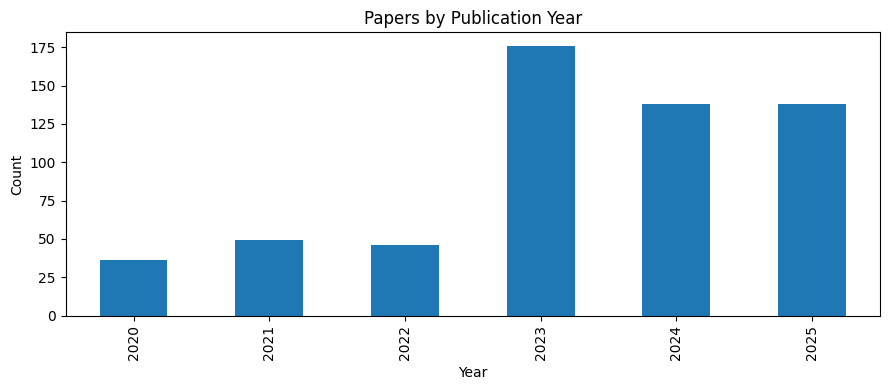

In [6]:
if col_map.get("year"):
    year_col = col_map["year"]
    fig, ax = plt.subplots(figsize=(9, 4))
    df[year_col].dropna().astype(int).value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title("Papers by Publication Year")
    ax.set_xlabel("Year"); ax.set_ylabel("Count")
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / "01_papers_by_year.png", dpi=150)
    plt.show()


## Citation statistics

count      583.000000
mean       617.492281
std       1164.486284
min          7.000000
25%         58.000000
50%        193.000000
75%        724.000000
max      12607.000000
Name: citation_count, dtype: float64


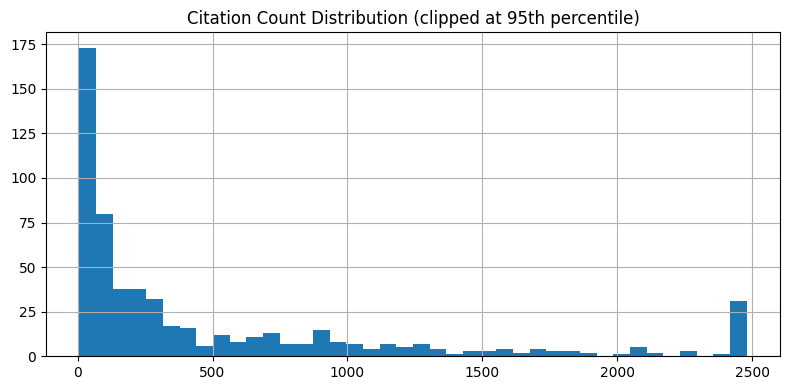

In [7]:
if col_map.get("citation_count"):
    cc = df[col_map["citation_count"]]
    print(cc.describe())
    fig, ax = plt.subplots(figsize=(8, 4))
    cc.clip(upper=cc.quantile(0.95)).hist(bins=40, ax=ax)
    ax.set_title("Citation Count Distribution (clipped at 95th percentile)")
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / "01_citation_distribution.png", dpi=150)
    plt.show()


## Abstract & title length statistics

In [8]:
if col_map.get("abstract"):
    abs_len = df[col_map["abstract"]].astype(str).str.len()
    print("Abstract length (chars):\n", abs_len.describe())
if col_map.get("title"):
    title_len = df[col_map["title"]].astype(str).str.len()
    print("\nTitle length (chars):\n", title_len.describe())


Abstract length (chars):
 count     583.000000
mean     1418.885077
std       493.398362
min       306.000000
25%      1096.000000
50%      1347.000000
75%      1645.500000
max      4332.000000
Name: abstract, dtype: float64

Title length (chars):
 count    583.000000
mean      80.377358
std       25.765963
min       13.000000
25%       63.000000
50%       78.000000
75%       94.000000
max      181.000000
Name: title, dtype: float64


## Papers by venue

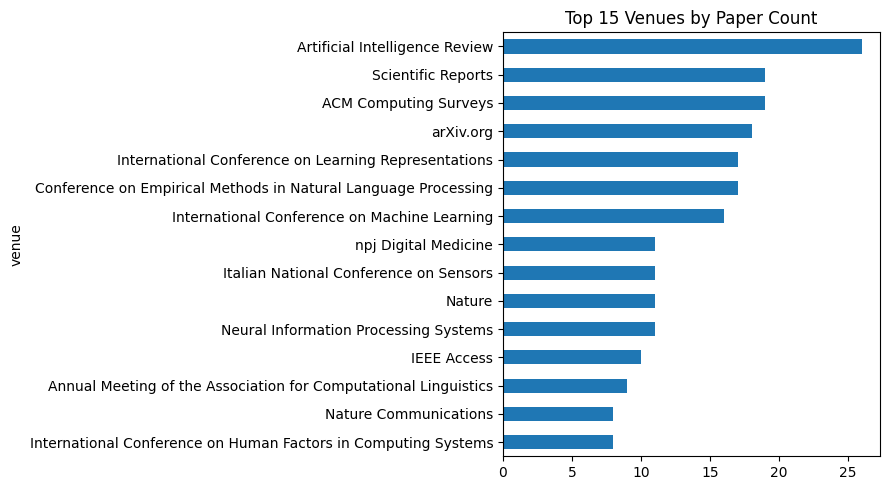

In [9]:
if col_map.get("venue"):
    top_venues = df[col_map["venue"]].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(9, 5))
    top_venues.sort_values().plot(kind="barh", ax=ax)
    ax.set_title("Top 15 Venues by Paper Count")
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / "01_top_venues.png", dpi=150)
    plt.show()


## Papers by field of study

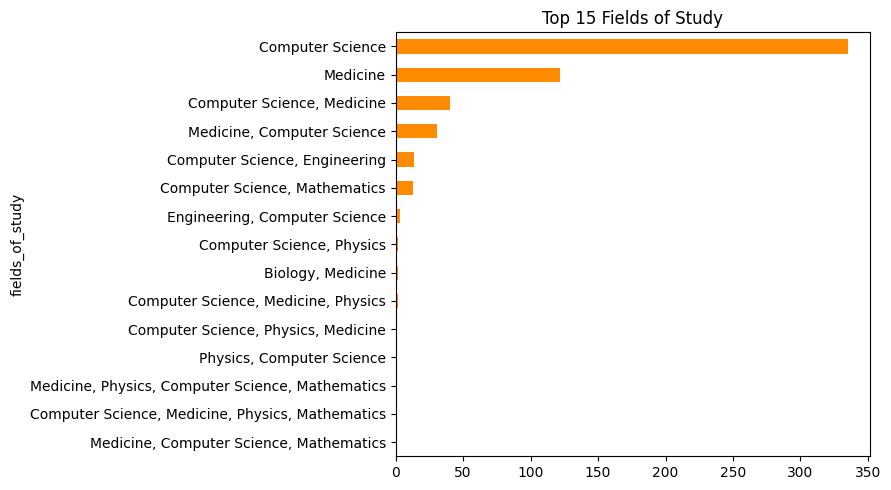

In [10]:
if col_map.get("fields_of_study"):
    fields = df[col_map["fields_of_study"]].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(9, 5))
    fields.sort_values().plot(kind="barh", ax=ax, color="darkorange")
    ax.set_title("Top 15 Fields of Study")
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / "01_fields_of_study.png", dpi=150)
    plt.show()


## Basic dataset quality report

In [11]:
from src.preprocessing import validate_dataset
report = validate_dataset(df)
import json
print(json.dumps(report, indent=2, default=str))


{
  "num_rows": 583,
  "num_columns": 24,
  "columns_present": {
    "paper_id": "paper_id",
    "title": "title",
    "abstract": "abstract",
    "authors": "authors",
    "year": "year",
    "venue": "venue",
    "url": "url",
    "citation_count": "citation_count",
    "reference_count": "reference_count",
    "publication_date": "publication_date",
    "fields_of_study": "fields_of_study",
    "influential_citation_count": "influential_citation_count",
    "tldr": "tldr",
    "research_topic": "research_topic"
  },
  "columns_missing": [],
  "has_search_text": false,
  "duplicate_titles": 0
}
